# ECON4002 — Week 2: Linear Algebra in R

**University of Western Australia**  
*Matrix operations, determinants, inverses, and solving linear systems*

---

## Key Formulae

Exponential growth: $Q(t) = Q_0 e^{rt}$. Logarithm: $\ln(e^x) = x$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 2 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 2: Linear Algebra in R — ready!\n')

Week 2: Linear Algebra in R — ready!


## Matrix Creation

### W2-CS01 — Create Matrix by Row

> **Note:** byrow=TRUE fills matrix row by row. Default is column by column.

In [ ]:
A <- matrix(c(1, 2, 3, 4, 5, 6), nrow = 2, ncol = 3, byrow = TRUE)
A

### W2-CS02 — Special Matrices

> **Note:** diag(n) creates n×n identity. diag(vector) creates diagonal matrix.

In [ ]:
# Identity matrix
I <- diag(3)

# Diagonal matrix
D <- diag(c(2, 3, 4))

# Zero matrix
Z <- matrix(0, nrow = 2, ncol = 3)

## Matrix Operations

### W2-CS03 — Matrix Multiplication

> **Note:** CRITICAL: Always use %*% for matrix multiplication. The * operator does element-wise multiplication.

In [ ]:
A <- matrix(c(1, 2, 3, 4), nrow = 2, byrow = TRUE)
B <- matrix(c(5, 6, 7, 8), nrow = 2, byrow = TRUE)

# CORRECT: Matrix multiplication
A %*% B

# WRONG: Element-wise multiplication
# A * B  # Don't use this for matrix mult!

### W2-CS04 — Transpose

> **Note:** Rows become columns. Dimension changes from m×n to n×m.

In [ ]:
A <- matrix(c(1, 2, 3, 4, 5, 6), nrow = 2, byrow = TRUE)
t(A)

## Determinants

### W2-CS05 — Calculate Determinant

> **Note:** For 2×2: det([[a,b],[c,d]]) = ad - bc. det ≠ 0 means inverse exists.

In [ ]:
# 2×2 determinant
A <- matrix(c(3, 2, 1, 4), nrow = 2, byrow = TRUE)
det(A)  # 3*4 - 2*1 = 10

# 3×3 determinant
B <- matrix(c(1, 2, 3, 7, 0, 8, 4, 5, 6), nrow = 3, byrow = TRUE)
det(B)  # 45

## Inverse

### W2-CS06 — Matrix Inverse

> **Note:** solve(A) returns A^(-1). Only works if det(A) ≠ 0.

In [ ]:
A <- matrix(c(2, 1, 3, 5), nrow = 2, byrow = TRUE)

# Find inverse
A_inv <- solve(A)

# Verify: A × A^(-1) = I
round(A %*% A_inv, 10)

## Linear Systems

### W2-CS07 — Solve Linear System

> **Note:** solve(A, b) is more efficient than solve(A) %*% b

In [ ]:
# Solve: 2x + y = 8
#        3x + 5y = 19

A <- matrix(c(2, 1, 3, 5), nrow = 2, byrow = TRUE)
b <- c(8, 19)

x <- solve(A, b)
x  # x = 3, y = 2

# Verify
A %*% x  # Should equal b

### W2-CS08 — Cramer's Rule

> **Note:** x_i = det(A_i) / det(A) where A_i has column i replaced by b

In [ ]:
cramers_rule <- function(A, b) {
  det_A <- det(A)
  if (abs(det_A) < 1e-10) stop("Singular matrix")
  
  n <- length(b)
  x <- numeric(n)
  
  for (i in 1:n) {
    A_i <- A
    A_i[, i] <- b  # Replace column i
    x[i] <- det(A_i) / det_A
  }
  return(x)
}

A <- matrix(c(2, 1, 3, 5), nrow = 2, byrow = TRUE)
b <- c(8, 19)
cramers_rule(A, b)  # 3, 2

## Economics

### W2-CS09 — Market Equilibrium Matrix Form

> **Interpretation:** Unique equilibrium exists because det(A) = -6 ≠ 0

In [ ]:
# Qd = 100 - 2P  →  Q + 2P = 100
# Qs = -20 + 4P  →  Q - 4P = -20

A <- matrix(c(1, 2, 1, -4), nrow = 2, byrow = TRUE)
b <- c(100, -20)

eq <- solve(A, b)
Q_star <- eq[1]
P_star <- eq[2]

cat("P* =", P_star, ", Q* =", Q_star)

### W2-CS10 — Two-Market System

> **Interpretation:** Cross-price effects captured in off-diagonal elements

In [ ]:
# Wheat: 5Pw - Pc = 90
# Corn: -Pw + 7Pc = 120

A <- matrix(c(5, -1, -1, 7), nrow = 2, byrow = TRUE)
b <- c(90, 120)

prices <- solve(A, b)
Pw <- prices[1]
Pc <- prices[2]

cat("Wheat price:", round(Pw, 2))
cat("Corn price:", round(Pc, 2))

### W2-CS11 — Leontief Input-Output

> **Interpretation:** Accounts for direct and indirect input requirements

In [ ]:
# Technology matrix
A <- matrix(c(0.2, 0.4, 0.1, 0.2), nrow = 2, byrow = TRUE)
d <- c(80, 60)  # Final demand

# Leontief solution: x = (I - A)^(-1) × d
I <- diag(2)
leontief <- solve(I - A)
x <- leontief %*% d

cat("Total output:", round(x, 1))

## Eigenvalues

### W2-CS12 — Eigenvalues for Definiteness

> **Note:** Pos def: all eigenvalues > 0. Neg def: all < 0. Indefinite: mixed signs.

In [ ]:
# Quadratic form: Q = 2x1² + 3x2² + 2x1x2
A <- matrix(c(2, 1, 1, 3), nrow = 2, byrow = TRUE)

eig <- eigen(A)
eig$values  # 3.618, 1.382

# All positive → positive definite
if (all(eig$values > 0)) {
  cat("Positive definite: minimum exists")
}

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

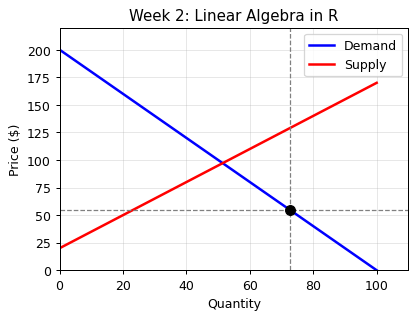

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Solve Economic System**

```r
A <- matrix(c(...), nrow=n, byrow=TRUE)
b <- c(...)
if (abs(det(A)) > 1e-10) {
  solution <- solve(A, b)
} else {
  cat('No unique solution')
}
```

**Check Invertibility**

```r
if (abs(det(A)) > 1e-10) {
  A_inv <- solve(A)
} else {
  warning('Matrix is singular')
}
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `non-conformable arguments` | Matrix dimensions don't match for multiplication | Check dim(A) and dim(B). For A %*% B, need ncol(A) = nrow(B) |
| `system is exactly singular` | det(A) = 0, no inverse exists | Check det(A). If 0, system has infinite or no solutions |
| `Wrong numerical results` | Used * instead of %*% | Always use %*% for matrix multiplication |